In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df1 = pd.read_csv('../results/run_0.csv')
df2 = pd.read_csv('../results/run_1_wm.csv')
df3 = pd.read_csv('../results/baseline.csv')
df = pd.concat([df1, df2, df3], ignore_index=True)
df

,infile,capacity_mb,key_sample_ratio,evict_expired,rv_enable,rv_min_ttl,rv_min_freq,rv_max_zone_amp,all,hit_fresh,hit_reval,hit_stale,miss_mandatory,miss_expired,miss_evicted,fetches,revals,reval_wasted
0,cf_a,2048,1,True,True,5.000000e+00,8.000000e+00,2,611934080,545785493,2058289,0,39393977,0,24696321.0,64090298,2821036,754241
1,cf_a,2048,1,True,True,5.000000e+00,5.000000e+00,2,611934080,545638894,2975422,0,39393977,0,23925787.0,63319764,4291683,1300708
2,cf_a,2048,1,True,True,5.000000e+00,2.000000e+00,2,611934080,545113041,5663957,0,39393977,0,21763105.0,61157082,11235478,5509903
3,cf_a,2048,1,True,True,1.000000e+00,3.000000e+00,2,611934080,545375383,4409159,0,39393977,0,22755561.0,62149538,7179933,2738129
4,cf_a,2048,1,True,True,1.000000e+00,4.000000e+00,2,611934080,545536168,3572557,0,39393977,0,23431378.0,62825355,5363625,1769924
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
450,fb23_a,2048,1,True,True,1.844674e+19,1.844674e+19,2,50114817,26091890,0,0,14706046,0,9316881.0,24022927,0,0
451,cf_g,2048,1,True,True,1.844674e+19,1.844674e+19,2,305423259,255767540,0,0,30637283,0,19018436.0,49655719,0,0
452,cf_a,2048,1,True,True,1.844674e+19,1.844674e+19,2,611934080,545938888,0,0,39393977,0,26601215.0,65995192,0,0
453,wm_a,2048,1,True,True,1.844674e+19,1.844674e+19,2,197819321,150948216,0,0,17895056,0,28976049.0,46871105,0,0


In [3]:
df['miss_all'] = df.miss_mandatory + df.miss_expired + df.miss_evicted
df['reval_pending'] = df.revals - df.hit_reval - df.reval_wasted

df['fresh_pc'] = df.hit_fresh / df['all'] * 100
df['reval_pc'] = df.hit_reval / df['all'] * 100
df['miss_pc'] = df['miss_all'] / df['all'] * 100
df['miss_non1st_pc'] = (df.miss_expired + df.miss_evicted) / df['all'] * 100

df['amp_lower'] = df['reval_wasted'] / (df['miss_all'] + df['hit_reval']) + 1
df['amp_upper'] = (df['reval_wasted'] + df['reval_pending']) / (df['miss_all'] + df['hit_reval']) + 1
df['amp_avg'] = (df['amp_lower'] + df['amp_upper']) / 2

df['ttl'] = df.rv_min_ttl
df['freq'] = df.rv_min_freq

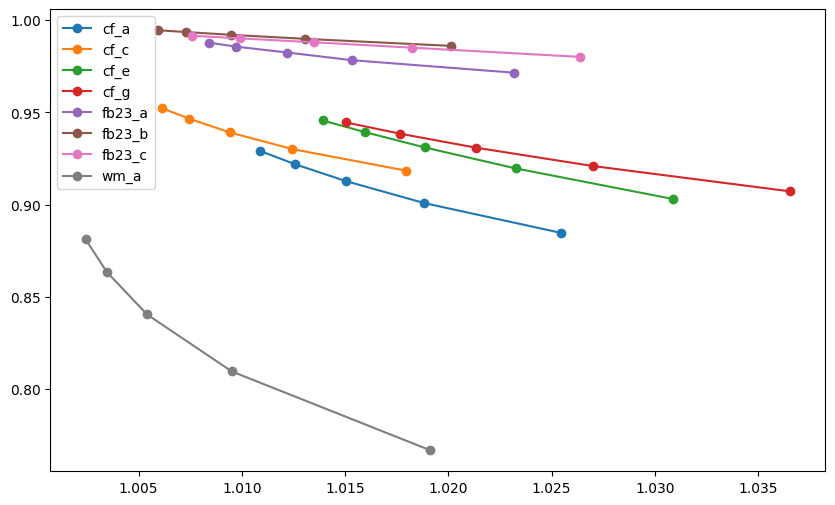

In [ ]:
plt.figure(figsize=(10,6))

for infile in sorted(df.infile.unique())[:]:
    dfi = df[(df.infile == infile) & (df.ttl == 30) & (df.freq >= 4)]
    dfi = dfi.sort_values(by='amp_avg')
    # normalise by maximum miss_non1st_pc for this infile
    max_miss = df[df.infile == infile].miss_non1st_pc.max()
    plt.plot(dfi.amp_avg, dfi.miss_non1st_pc / max_miss, label=infile, marker='o')

plt.xlabel('Origin request amplification')
plt.ylabel('Normalised non-mandatory miss ratio')
plt.legend()
plt.show()

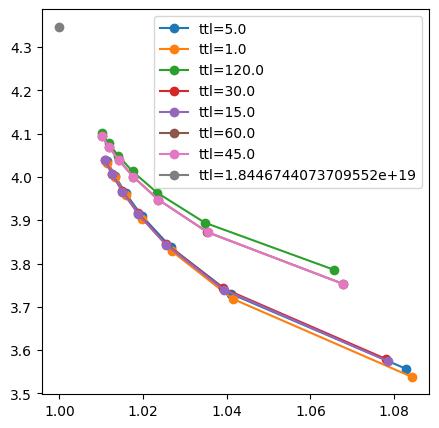

In [26]:
plt.figure(figsize=(5,5))
for ttl in df.ttl.unique():
    dfi = df[(df.infile == 'cf_a') & (df.ttl == ttl) & (df.freq >= 2)]
    dfi = dfi.sort_values(by='amp_avg')
    plt.plot(dfi.amp_avg, dfi.miss_non1st_pc, label=f'ttl={ttl}', marker='o')
plt.legend()
plt.show()

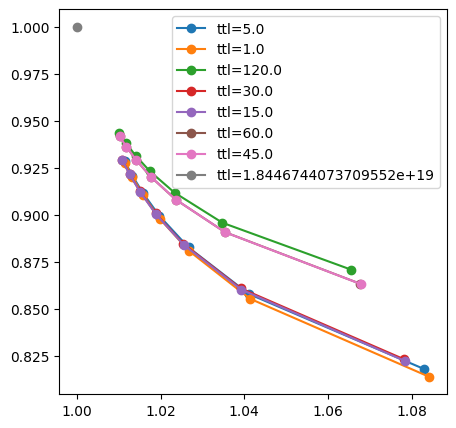

In [27]:
plt.figure(figsize=(5,5))
baseline = df[(df.infile == 'cf_a') & (df.freq >= 0)].miss_non1st_pc.max()
for ttl in df.ttl.unique():
    dfi = df[(df.infile == 'cf_a') & (df.ttl == ttl) & (df.freq >= 2)]
    dfi = dfi.sort_values(by='amp_avg')
    plt.plot(dfi.amp_avg, dfi.miss_non1st_pc / baseline, label=f'ttl={ttl}', marker='o')
plt.legend()
plt.show()

ValueError: 'c' argument must be a color, a sequence of colors, or a sequence of numbers, not 'rv_min_ttl'

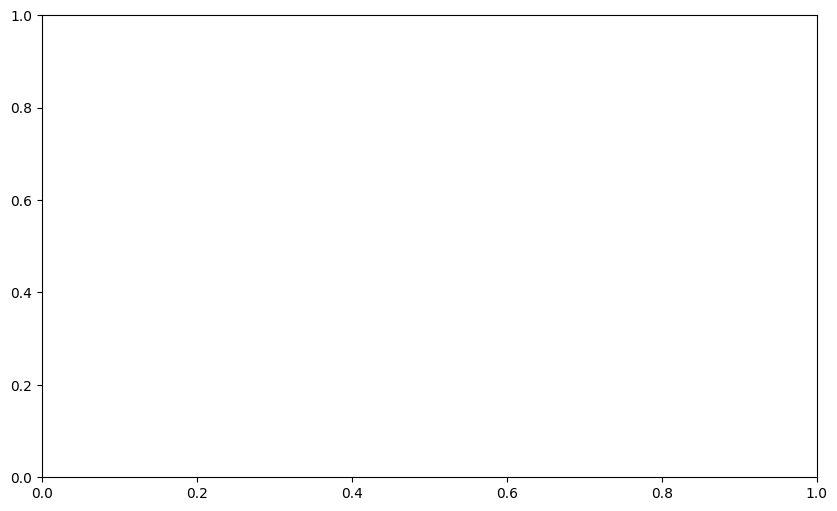

In [76]:
dfp.plot.scatter(x='amp_avg', y='miss_non1st_pc', c='rv_min_ttl', colormap='viridis', s=3, figsize=(10,6), title='Cache Miss Rate vs Revalidation Amplification')